<a href="https://colab.research.google.com/github/Thangapandi1611/ml-safety-project/blob/main/week4/EDA_CARLA_DATA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#lOADING dATA
train_path = "/content/drive/MyDrive/MLS_DATA/train/train"
test_path = "/content/drive/MyDrive/MLS_DATA/test/test"

In [3]:
#lOADING PACKAGES
import pandas as pd
import matplotlib.pyplot as plt
import os
from PIL import Image

In [4]:
labels = pd.read_csv(
    "/content/drive/MyDrive/MLS_DATA/train/labels.csv"
)

In [5]:
labels.head()

,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
0,0,False,False,True,0,0,85
1,10,False,True,True,14,301,1138
2,20,True,True,True,99,196,517
3,30,True,True,True,99,181,530
4,40,True,True,True,101,169,538


In [6]:
labels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7200 entries, 0 to 7199
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   frame              7200 non-null   int64
 1   has_traffic_light  7200 non-null   bool 
 2   has_pedestrian     7200 non-null   bool 
 3   has_vehicle        7200 non-null   bool 
 4   px_traffic_light   7200 non-null   int64
 5   px_pedestrian      7200 non-null   int64
 6   px_vehicle         7200 non-null   int64
dtypes: bool(3), int64(4)
memory usage: 246.2 KB


In [7]:
labels.describe()

,frame,px_traffic_light,px_pedestrian,px_vehicle
count,7200.000000,7200.000000,7200.000000,7200.000000
mean,35995.000000,218.503611,70.369306,2259.733889
std,20786.053016,310.809585,217.723742,4085.054794
min,0.000000,0.000000,0.000000,0.000000
25%,17997.500000,33.000000,0.000000,44.000000
50%,35995.000000,136.000000,2.000000,363.000000
75%,53992.500000,343.000000,34.000000,1892.250000
max,71990.000000,4199.000000,4219.000000,27791.000000


In [8]:
labels['has_pedestrian'].value_counts()

,count
has_pedestrian,
False,5482
True,1718


In [9]:
labels['has_vehicle'].value_counts()

,count
has_vehicle,
True,5458
False,1742


In [10]:
labels['has_traffic_light'].value_counts()

,count
has_traffic_light,
True,5276
False,1924


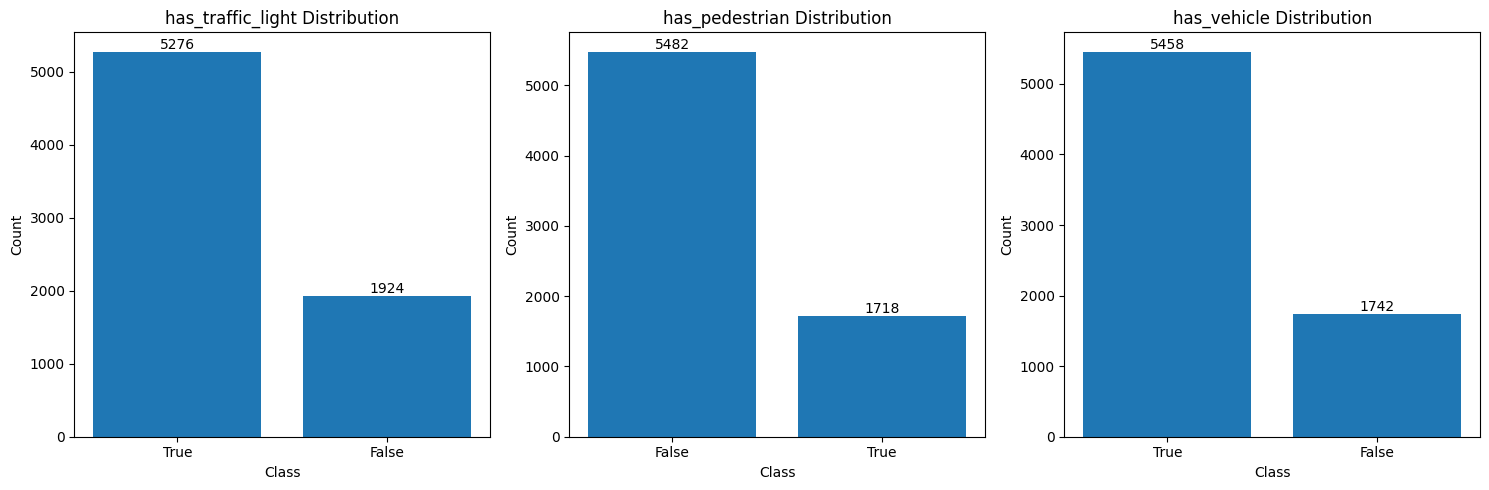

In [14]:
import matplotlib.pyplot as plt

# Labels to analyze
columns = ['has_traffic_light', 'has_pedestrian', 'has_vehicle']

# Create figure
fig, axes = plt.subplots(1, 3, figsize=(15,5))

for i, col in enumerate(columns):
    counts = labels[col].value_counts()
    bars = axes[i].bar(
        counts.index.astype(str),
        counts.values
    )

    # Titles and labels
    axes[i].set_title(f'{col} Distribution')
    axes[i].set_xlabel('Class')
    axes[i].set_ylabel('Count')

    # Add count labels
    for bar in bars:
        height = bar.get_height()
        axes[i].text(
            bar.get_x() + bar.get_width()/2,
            height,
            str(height),
            ha='center',
            va='bottom'
        )

plt.tight_layout()
plt.show()

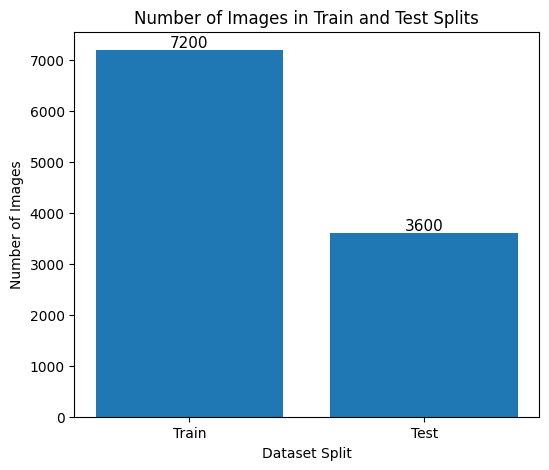

In [11]:
import os
import matplotlib.pyplot as plt

# Paths
train_rgb_path = "/content/drive/MyDrive/MLS_DATA/train/rgb-front"
test_rgb_path = "/content/drive/MyDrive/MLS_DATA/test/rgb-front"

# Count images
train_count = len(os.listdir(train_rgb_path))
test_count = len(os.listdir(test_rgb_path))

# Data
splits = ['Train', 'Test']
counts = [train_count, test_count]

# Create bar chart
plt.figure(figsize=(6,5))

bars = plt.bar(splits, counts)

# Add count labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        str(height),
        ha='center',
        va='bottom',
        fontsize=11
    )

# Labels and title
plt.title("Number of Images in Train and Test Splits")
plt.xlabel("Dataset Split")
plt.ylabel("Number of Images")

plt.show()

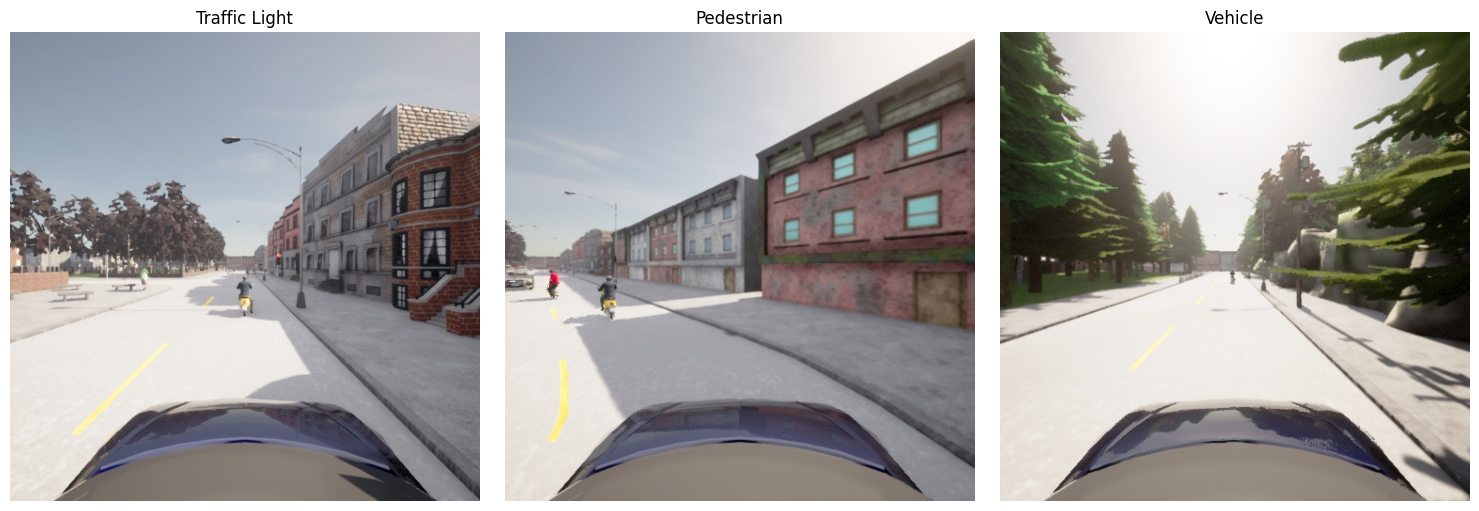

In [24]:
#Displaying Images of each pattern
import matplotlib.pyplot as plt
from PIL import Image
import os

# Dataset path
rgb_path = "/content/drive/MyDrive/MLS_DATA/train/rgb-front"

# Labels to visualize
categories = {
    "Traffic Light": "has_traffic_light",
    "Pedestrian": "has_pedestrian",
    "Vehicle": "has_vehicle"
}


plt.figure(figsize=(15,5))

for i, (title, column) in enumerate(categories.items()):
    found_image = False
    # Get all samples where the current column is True
    matching_samples = labels[labels[column] == True]

    for idx, sample in matching_samples.iterrows(): # Iterate through matching samples
        frame = sample['frame']
        img_path = os.path.join(rgb_path, f"{frame:06d}.jpg") # Changed from .png to .jpg

        if os.path.exists(img_path):
            img = Image.open(img_path)
            plt.subplot(1,3,i+1)
            plt.imshow(img)
            plt.title(title)
            plt.axis("off")
            found_image = True
            break # Found an image, move to next category

    if not found_image:
        plt.subplot(1,3,i+1)
        plt.text(0.5, 0.5, f"Image for '{title}' not found", horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes)
        plt.title(title)
        plt.axis("off")

plt.tight_layout()
plt.show()